# **Mestrado em Informática**
## *Aprendizagem Máquina*

# **Pós-Graduação em Data Science and Digital Transformation**

## *Análise de Dados e Aprendizagem Automática*

Mónica Vieira Martins
---------------------


># Tutorial 09 - Redes Neuronais

Neste tutorial usa-se o conjunto de dados referentes ao naufrágio do Titanic trabalhado nos tutoriais anteriores para exemplificar a construção, treino, e teste de modelos de redes neuronais. Mais uma vez, o objetivo é prever a sobrevivência dos passageiros.

Vai-se usar a biblioteca open-source  **TensorFlow** e com a API **Keras**, ambas opções populares para treinar modelos de redes neuronais.



## **TensorFlow** e **Keras**

O **TensorFlow** é uma biblioteca *open source* desenvolvida pela Google para computação numérica e aprendizagem máquina, especialmente adequada à criação de modelos de redes neuronais e aprendizagem profunda.

O **Keras** é uma interface do TensorFlow, facilitanto a construção, treino, avaliação e aplicação de modelos, sendo de utilização muito intuitiva.


## Dados

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline
#sns.set_style("whitegrid")

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score, accuracy_score

In [4]:
#ler os dados para data frames

train=pd.read_csv("titanic_train.csv")
test=pd.read_csv("titanic_test.csv")

In [5]:
print(train.shape)
print(test.shape)

(712, 8)
(179, 8)


In [6]:
#Inicializar as variáveis independentes de teste e treino
ytrain = train[["Survived"]]
ytest = test[["Survived"]]


In [7]:
#Inicializar as variáveis dependentes de teste e treino
Xtrain = train.drop("Survived", axis=1)
Xtest = test.drop("Survived", axis=1)
Xtrain.head()

,Pclass,Age,Fare,FamilySize,Sex,Embarked_1,Embarked_0
0,3.0,29.745184,15.2458,2.0,0.0,0.0,0.0
1,2.0,31.000000,10.5000,0.0,1.0,0.0,1.0
2,2.0,31.000000,37.0042,2.0,1.0,0.0,0.0
3,3.0,20.000000,4.0125,0.0,1.0,0.0,0.0
4,3.0,21.000000,7.2500,0.0,1.0,0.0,1.0


Para treinar um modelo de redes neuronais, é imperioso que os dados sejam padronizados, pois, de outra forma, o algoritmo de propagação e retropropagação será mais influenciado por atributos com valores numéricos mais elevados.   
Como nos tutoriais anteriores, usamos o `RobustScaler()` para padronização dos dados.

In [8]:
from sklearn.preprocessing import RobustScaler
#TODO -Normalizar os dados usando o RobustScaler
RScaler = RobustScaler()
Xtrain_RScl = pd.DataFrame(RScaler.fit_transform(Xtrain), columns=Xtrain.columns)
Xtest_RScl = pd.DataFrame(RScaler.transform(Xtest), columns=Xtrain.columns)


## Definição de Funções

Função para impressão do gráfico da matriz de confusão e do relatório de classificação

In [9]:
#Data frame para registo de performance
performance = pd.DataFrame(columns=['Train Accuracy','Test Accuracy', "Test f1"])

In [10]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score
rotulos=["Não sobreviveu", "Sobreviveu"]

def model_evaluation(acc_train, verdadeiros, previstos,  titulo):
  ''' Função que cria e imprime a
    matriz de confusão de um dados modelo e respetivo relatório de classificação
    preenche o df calssification report
    verdadeitos - rotulos evrdadeiros do conjunto de teste
    previstos - rotulos previstos pelo modelo no conjunto de teste
    acc_train - exatidão do modelo no conjunto de treino, calculada previamente
    titulo - nome do modelo
  '''
  conf_matrix =  confusion_matrix(verdadeiros, previstos,  normalize="true")
  s = sns.heatmap(conf_matrix, annot=True, cmap="Greens",
              xticklabels=rotulos, yticklabels=rotulos)
  s.set(xlabel = "Rótulo Previsto", ylabel="Rótulo Verdadeiro", title=titulo)
  plt.show()
  print(classification_report(verdadeiros, previstos))
  #preencher DF com resumo da performance
  #Avaliar o modelo com a exatidão


  acc_test= accuracy_score(verdadeiros, previstos)
  f1 = f1_score(verdadeiros, previstos, average="macro" )

  performance.loc[titulo,
                  ["Train Accuracy","Test Accuracy", "Test f1"]] =[
                  f"{acc_train:.2f}",
                  f"{acc_test:.2f}",
                  f"{f1:.2f}"]


# Construir uma rede neuronal  com  uma camada

Como se disse,  vamos utilizar a API `keras`, que utiliza a biblioteca `TensorFlow`, optimizada para criar e treinar redes neuronais e redes neuronais profundas, incluindo a possibilidade de utilizar GPU no treino dos modelos.

In [11]:
import tensorflow as tf

O Colab disponibiliza tempo de GPU. Para o usar,  altera-se  o acelerador  de hardware em Runtime->Change runtime type, escolhendo o GPU que estiver disponível

A informação mais detalhada sobre a utilização de GPU no colab encontra-se aqui: https://research.google.com/colaboratory/faq.html#gpu-availability

A célula de código seguinte verifica se efetivamente se  estaá a trabalhar com o GPU.

In [12]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
   raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


Podemos agora importar `keras` e as classes necessárias para construir a rede neuronal.

Com  `keras`, utiliza-se a classe `Sequencial`  para definir a rede neuronal como uma sequência de camadas (layers)  e a classe  `Dense`, para definir os atributos de cada camada *densa* do modelo.  
Por camada densa entende-se uma camada em que todos os neurónios estão ligaods aos neurónios da camada adjacente.  

In [13]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import metrics

A construção de uma rede neuronal com Keras (em cima do TensorFlow) segue uma lógica simples e modular, composta por três passos principais:
1. **Definir a arquitetura da rede neuronal**
2. **Compilar a rede**
3. **Treinar o modelo com os dados de treino.**

## Definir a arquitetura da rede neuronal

A arquitetura de uma rede neuronal de classificação pode variar bastante dependendo do problema em questão. No entanto, existem alguns elementos fundamentais que todas as redes neuronais profundas contêm:

- Uma camada de entrada

- Algumas camadas escondidas

- Uma camada de saída

Neste primeiro exemplo vamos construir uma rede simples, com apenas uma camada escondida, para entender o fluxo básico.





Com Keras, a forma mais simples de criar uma rede é usar a classe `Sequential()`, que permite empilhar camadas de forma linear, uma a seguir à outra.   
Em seguida, é necessário adicionar as camadas da rede.

Adicionamos camadas  usando o método `add()`.
O  tipo de camadas que iremos usar neste trabalho são:
- *Input* - define a camada de entrada. Tem como atributo `shape`, que define o número de unidades de entrada na rede
- *Dense* - define uma camada densa, isto é, uma camada em que cada  neurónio está completamente ligado a todos os neurónios das camadas adjacentes.

A tabela seguinte lista alguns dos parâmetros mais importantes da camada `Dense()`

 Parâmetro       | Descrição                                                                 |
|------------------|---------------------------------------------------------------------------|
| `units`          | Número de neurónios (ou nós) nesta camada. Define a dimensão da saída.   |
| `activation`     | Função de ativação aplicada aos neurónios (ex: `'relu'`, `'sigmoid'`).   |
| `use_bias`       | Indica se se deve incluir um termo de bias (default: `True`).            |
| `kernel_initializer` | Inicializador dos pesos (por omissão, `'glorot_uniform'`).  |
| `bias_initializer`   | Inicializador do bias (por omissão: `'zeros'`).                              |
| `kernel_regularizer` | Aplica regularização aos pesos (não usado neste tutorial).          |
| `bias_regularizer`   | Aplica regularização ao bias (não usado neste tutorial).                                        |
| `name`           | Nome opcional da camada (útil para identificar camadas em modelos grandes). |


Relativamente à função de ativação da camada, a combinação mais comum nas redes neuronais para classificação é:
* as camadas interiores usar-se a função de retificação linear (`relu`).
* na última camada usa-se a função sigmóide (`sigmoid`)se a classificação for  binária.
* na última camada usa-se  `soft_max` se a classificação for multiclasse.


Vamos então criar a arquitetura da primeira rede, apenas com uma camada escondida.  
Na camada interna vamos usar um valor pequeno - 8.  
O número de neurónios de entrada corresponde ao número de caraterísticas dos dados de treino.  
O número de neurónios da camada de saída é 1, pois trata-se de uma classifacação binária.  
Tosos os restantes argumentos são os hatituais, conforme explicado acima.


In [14]:
Xtrain.shape[1]

7

In [15]:
Xtrain.shape

(712, 7)

In [16]:
#Instanciar o modelo
rn1 = Sequential()
#Adicionar a camada de entrada
rn1.add(Input(shape=(Xtrain.shape[1],)))
#Adicionar a 1ª camada oculta, neste caso com apenas 5 neurónios
rn1.add(Dense(5, activation='relu'))
#Adicionar a camada de saída, com 1 neurónio
rn1.add(Dense(1, activation='sigmoid'))

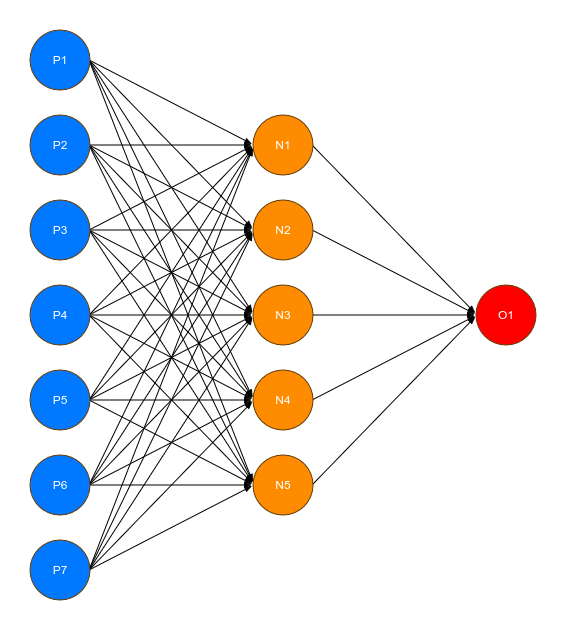

O método `summary()` permite visualizar a dimensão de cada camada e a arquitetura da rede

In [17]:
rn1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46 (184.00 B)

 Trainable params: 46 (184.00 B)

 Non-trainable params: 0 (0.00 B)

## Compilar a rede

Em seguida, é necessário compilar a rede. Fazemo-lo usando o método `compile()`, que nos permite definir os seguintes parâmetros:

*  `optimizer`: trata-se do algoritmo  utilizado para encontrar o conjunto óptimo de pesos para a rede.O mais comum é utilizar-se um algoritmo baseado no gradiente decrescente estocástico (stochastic gradient descent), SGD. O Tensor Flow tem vários tipos de algoritmo SGD implementados. Um dos mais eficientes ( e mais usados) chama-se **`adam`**.
* `loss`: a função de custo, ou seja, a função que vai ser minimizada pelo algoritmo de optmização. Para um algoritmo SGD, usa-se uma função de custo logística: entropia cruzada. No TensorFlow, se a variável dependente for binária, utiliza-se **`binary_crossentropy`**; se a variável tiver mais do que duas categorias, usa-se **`categorical_crossentropy`**.
* `metrics`: lista de métricas utilizadas para avaliar o desempenho da rede. Como temos vindo a fazer, vamor usar a exatidão.

In [18]:
#compilar a rede criada
rn1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Treinar a rede
Estamos agora em condições de treinar a rede, usando um método `fit()` e os dados de treino. Adicionalmente.  
Pode-se ainda definir os seguintes parâmetros:
* **`batch_size`**: número de observações (input) que é fornecido ao modelo de cada vez que é feita uma atualização nos pesos.  Se houver N atributos e o `batch size` for `b`, os pesos do modelo são atualizados `N/b` vezes  por cada passagem completa dos dados.   
O `batch_size` tem impacto no tempo de computação, na variância, e no erro, entre outros.  
É normal usarem-se valores baixos de batch_size por comparação com o número de exempares disponíveis nos dados de treino (16, 32, 64, 128, 256, ...).

* **`epochs`**: Uma época corresponde a uma passagem  completa do algoritmo pelo conjunto total de dados. O número de épocas deve ser suficientemente elevado para garantir que o algoritmo converge.

In [19]:
treino=rn1.fit(Xtrain_RScl, ytrain, batch_size=32, epochs = 120)

Epoch 1/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.4902 - loss: 0.8591
Epoch 2/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5393 - loss: 0.8244
Epoch 3/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5604 - loss: 0.7930 
Epoch 4/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5702 - loss: 0.7643 
Epoch 5/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5744 - loss: 0.7400 
Epoch 6/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5857 - loss: 0.7188 
Epoch 7/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5955 - loss: 0.6999 
Epoch 8/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6025 - loss: 0.6826 
Epoch 9/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6292 - loss: 0.6671 
Epoch 10/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6629 - loss: 0.6524 
Epoch 11/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6854 - loss: 0.6403 
Epoch 12/120
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

O objeto devolvido por `fit()` contém os valores da função de custo e da métrica para cada época.  
Com essa informação, é possivel construir gráficos para  visualização da evolução dessas duas quantidas ao longo do processo iterativo.      
Estes gráficos permitem ainda ter uma ideia se o modelo está a convergir, e quando.

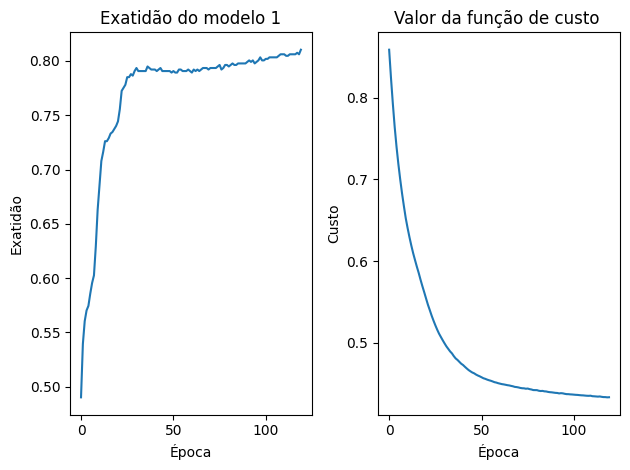

In [20]:
#exatidao
plt.subplot(1,2,1)
plt.plot(treino.history['accuracy'])
plt.title('Exatidão do modelo 1')
plt.ylabel('Exatidão')
plt.xlabel('Época')
# custo
plt.subplot(1,2,2)
plt.plot(treino.history['loss'])
plt.title('Valor da função de custo ')
plt.ylabel('Custo')
plt.xlabel('Época')

plt.tight_layout()
plt.show()

## Avaliar o resultado



Como costume, podemos gerar previsões para o conjunto de teste

In [21]:
ypred=(rn1.predict(Xtest_RScl))



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


Uma vez que estamos a usar a função sigmóide na camada de saída da rede, os valores gerados são contínuos, e compreendido entre 0 e 1. Multiplicando por 100, estes valores representam as probabilidades dos passageiros sobreviverem ou não.

Para comparar com os valores de ytest, teremos que transformar este valores em valores binários (0/1), aplicando um threshold. Por exemplo, podemos considerar que valores  acima de 0,5 representam a sobrevivência.

In [22]:
ypred=(ypred>0.5).astype('int64')
ytest=ytest.astype('int64')

Em seguida, usamos a função criada acima para avaliação do modelo

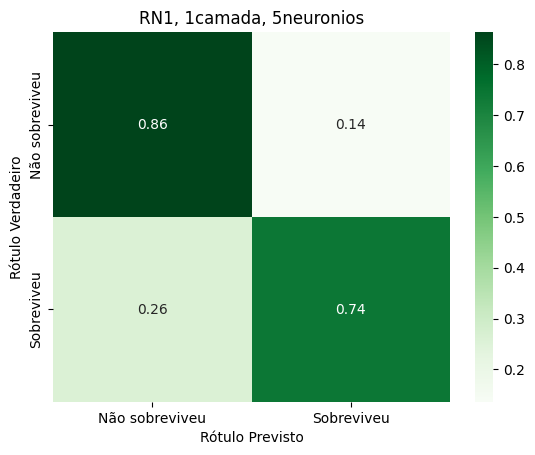

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       110
           1       0.77      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [23]:
model_evaluation(treino.history['accuracy'][-1], ytest, ypred, "RN1, 1camada, 5neuronios")

In [24]:
display(performance)

,Train Accuracy,Test Accuracy,Test f1
"RN1, 1camada, 5neuronios",0.81,0.82,0.80


## Em resumo

A tabela seguinte resume os valores standard frequentemente usados nas redes neuronais de classificação

| **Hiperparâmetro**          | **Classificação Binária**                                                                                   | **Classificação Multiclasse**                                                                   |
|----------------------------|-------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **Forma da camada de entrada** | Igual ao número de características (ex.: 5 para idade, sexo, altura, peso, estado de fumador...)          | Igual à classificação binária                                                                   |
| **Camada(s) escondida(s)** | Específico do problema, mínimo = 1, máximo = ilimitado                                                      | Igual à classificação binária                                                                   |
| **Neurónios por camada escondida** | Específico do problema, geralmente entre 10 e 100                                                  | Igual à classificação binária                                                                   |
| **Forma da camada de saída**   | 1 (uma classe ou outra)                                                                                 | 1 por classe                                                 |
| **Função de ativação escondida** | Normalmente [ReLU](https://en.wikipedia.org/wiki/Rectifier_(neural_networks))                         | Igual à classificação binária                                                                   |
| **Função de ativação de saída** | [Sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function)                                             | [Softmax](https://en.wikipedia.org/wiki/Softmax_function)                                       |
| **Função de perda**         | Entropia cruzada (`tf.keras.losses.BinaryCrossentropy`)                                                    | Entropia cruzada (`tf.keras.losses.CategoricalCrossentropy`)                                   |
| **Otimizador**              | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) | Igual à classificação binária |


## Estratégias para controlar o overfitting

### Validação cruzada

Como forma de controlar o *overfitting* e obter uma estimativa mais robusta da capacidade de generalização do modelo, utilizamos validação cruzada na fase de treino da rede.

Para garantir que é usada a validação cruzada, basta indicar o argumento do método `fit()` relativo à fração de dados no subconjunto de validação, `validation_split`. Na fase de treino, juntamente com a exatidão, será avaliada a exatidão de validação (`val_accuracy`); juntamente com o valor da função de custo, será avaliado o custo de validação (`val_loss`)


Segue-se o exmplo da rede anterior, agora treinada com validação

In [25]:
#Apagar o modelo já treinado, para voltar a treinar
del rn1

In [26]:
#Definir a arquitetura da rede
rn1 = Sequential()
#Adicionar a camada de entrada
rn1.add(Input(shape=(Xtrain.shape[1],)))
#Adicionar a 1ª camada oculta, neste caso com apenas 5 neurónios
rn1.add(Dense(5, activation='relu'))
#Adicionar a camada de saída, com 1 neurónio
rn1.add(Dense(1, activation='sigmoid'))
#compilar a rede criada
rn1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
#Treinar o modelo, com validação cruzada
treino=rn1.fit(Xtrain_RScl,ytrain, batch_size=32, epochs=120, validation_split=0.2)

Epoch 1/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4921 - loss: 0.7475 - val_accuracy: 0.5245 - val_loss: 0.7133
Epoch 2/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5132 - loss: 0.7214 - val_accuracy: 0.5175 - val_loss: 0.6950
Epoch 3/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5518 - loss: 0.7009 - val_accuracy: 0.5804 - val_loss: 0.6808
Epoch 4/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5940 - loss: 0.6835 - val_accuracy: 0.6224 - val_loss: 0.6690
Epoch 5/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6292 - loss: 0.6684 - val_accuracy: 0.6503 - val_loss: 0.6588
Epoch 6/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6362 - loss: 0.6554 - val_accuracy: 0.6434 - val_loss: 0.6502
Epoch 7/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6397 - loss: 0.6435 - val_accuracy: 0.6364 - val_loss: 0.6428
Epoch 8/120
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6450 - loss: 0.6336 - val_accuracy: 0.6434 

Podemos agora visualizar não só a exatidão a o custo relativos aos dados de treino, mas também aos dados de validação:

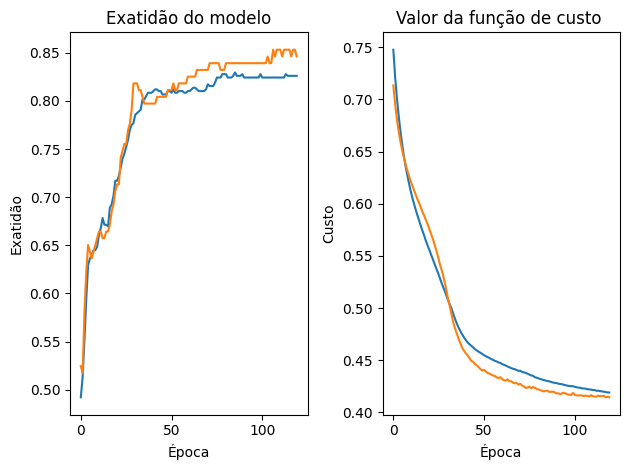

In [28]:
#exatidao
plt.subplot(1,2,1)
plt.plot(treino.history['accuracy'], label='Treino')
plt.plot(treino.history['val_accuracy'], label='Validação')
plt.title('Exatidão do modelo')
plt.ylabel('Exatidão')
plt.xlabel('Época')
#custo
plt.subplot(1,2,2)
plt.plot(treino.history['loss'], label = "Treino")
plt.plot(treino.history['val_loss'], label = "Validação")
plt.title('Valor da função de custo ')
plt.ylabel('Custo')
plt.xlabel('Época')

plt.tight_layout()
plt.show()


### Callback e EarlyStopping

Os **Callbacks** são outra das ferramentas do Keras que permitem controlar o treino do modelo.  
O `EarlyStopping`, por exemplo, termina o treino se o modelo não melhorar após um certo número de épocas. Esta abordagem pode ser útil para evitar o *overfitting*, poupa tempo de treino e garante que o modelo final é o melhor observado na fase de treino.

O `EarlyStopping` observa uma métrica (por exemplo, `val_loss`) em cada época de treino e pára o treino automaticamente se essa métrica deixar de melhorar durante um certo de número de épocas consecutivas (o parâmetro `patience`).  

In [29]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor = 'val_loss',  #métrica que vai ser monitorizada
                            patience = 10,  #número de épocas sem melhoria antes de parar
                            restore_best_weights = True #volta ao melhor modelo (não ao último)
                            )

Voltando a treinar o modelo anterior, agora com EarlyStopping

In [43]:
del rn1

Epoch 1/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6309 - loss: 0.7190 - val_accuracy: 0.5874 - val_loss: 0.7530
Epoch 2/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6432 - loss: 0.6939 - val_accuracy: 0.6014 - val_loss: 0.7220
Epoch 3/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6503 - loss: 0.6775 - val_accuracy: 0.6084 - val_loss: 0.7034
Epoch 4/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6538 - loss: 0.6658 - val_accuracy: 0.6224 - val_loss: 0.6891
Epoch 5/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6555 - loss: 0.6568 - val_accuracy: 0.6294 - val_loss: 0.6775
Epoch 6/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6608 - loss: 0.6482 - val_accuracy: 0.6434 - val_loss: 0.6681
Epoch 7/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6661 - loss: 0.6407 - val_accuracy: 0.6643 - val_loss: 0.6578
Epoch 8/150
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6714 - loss: 0.6334 - val_accuracy: 0.6783 - 

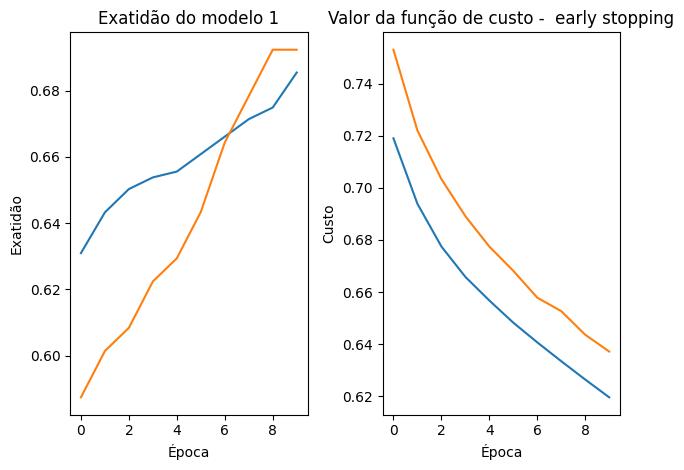

In [44]:
#DEfinir a arquitetura da rede
rn1 = Sequential()
#Adicionar a camada de entrada
rn1.add(Input(shape=(Xtrain.shape[1],)))
#Adicionar a 1ª camada oculta, neste caso com apenas 5 neurónios
rn1.add(Dense(5, activation='relu'))
#Adicionar a camada de saída, com 1 neurónio
rn1.add(Dense(1, activation='sigmoid'))
#compilar a rede
rn1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'] )

#treinar com Early Stopping e validação cruzada
treino = rn1.fit(
    Xtrain_RScl, ytrain,
    batch_size=16,
    epochs=150,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

#Visualização
#exatidao
plt.subplot(1,2,1)
plt.plot(treino.history['accuracy'], label='Treino')
plt.plot(treino.history['val_accuracy'], label='Validação')
plt.title('Exatidão do modelo - early stopping')
plt.title('Exatidão do modelo 1')
plt.ylabel('Exatidão')
plt.xlabel('Época')
#custo
plt.subplot(1,2,2)
plt.plot(treino.history['loss'], label = "Treino")
plt.plot(treino.history['val_loss'], label = "Validação")
plt.title('Valor da função de custo -  early stopping')
plt.ylabel('Custo')
plt.xlabel('Época')

plt.tight_layout()
plt.show()

In [45]:
ypred=(rn1.predict(Xtest_RScl))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [46]:
ypred=(ypred>0.5).astype('int64')
ytest=ytest.astype('int64')

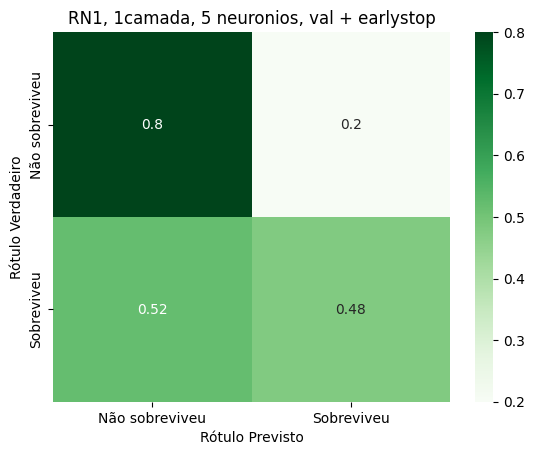

              precision    recall  f1-score   support

           0       0.71      0.80      0.75       110
           1       0.60      0.48      0.53        69

    accuracy                           0.68       179
   macro avg       0.65      0.64      0.64       179
weighted avg       0.67      0.68      0.67       179



In [47]:
model_evaluation(treino.history['accuracy'][-1], ytest, ypred, "RN1, 1camada, 5 neuronios, val + earlystop")

In [48]:

display(performance)

,Train Accuracy,Test Accuracy,Test f1
"RN1, 1camada, 5neuronios",0.81,0.82,0.80
"RN1, 1camada, 5 neuronios, val + earlystop",0.69,0.68,0.64
"RN1, 1camada, 8 neuronios",0.76,0.35,0.33


## Funções para automatização

In [35]:
def definir_modelo(units=[8]):
    modelo = Sequential()
    modelo.add(Input(shape=(Xtrain_RScl.shape[1],))) #camada de entrada
    modelo.add(Dense(units[0], activation = 'relu')) #primeira camada interna
    for u in units[1:]: #camadas internas seguintes, se aplicável
        modelo.add(Dense(u, activation = 'relu'))
    modelo.add(Dense(1, activation = 'sigmoid')) #camada de saída
    print(modelo.summary())
    modelo.compile(optimizer = 'adam', loss='binary_crossentropy', metrics=['accuracy'])
    return modelo

In [49]:
#treinar modelo com callback e validação
def treinar_modelo(modelo, Xtrain=Xtrain_RScl, ytrain=ytrain, epocas=100, batch = 16 ):
    early_stop = EarlyStopping(monitor = 'val_loss',  #métrica que vai ser monitorizada
                              patience = 10,  #número de épocas sem melhoria antes de parar
                              restore_best_weights = True #volta ao melhor modelo (não ao último)
                              )
    return modelo.fit(Xtrain, ytrain,
                    batch_size=batch,
                    validation_split = 0.2, epochs=epocas,
                    callbacks=early_stop, verbose=0)

In [54]:
def visualizar(nome,treino):
    #exatidao
    plt.title(nome)
    plt.subplot(1,2,1)
    plt.plot(treino.history['accuracy'], label='Treino')
    plt.plot(treino.history['val_accuracy'], label='Validação')
    plt.ylabel('Exatidão')
    plt.xlabel('Época')
    #custo
    plt.subplot(1,2,2)
    plt.plot(treino.history['loss'], label = "Treino")
    plt.plot(treino.history['val_loss'], label = "Validação")
    plt.ylabel('Custo')
    plt.xlabel('Época')

    # plt.tight_layout()
    plt.show()

In [51]:
# avaliar
def avaliar_modelo(modelo, treino, Xtest = Xtest_RScl, ytest = ytest, nome_modelo=" " ):
    acc_train=treino.history['accuracy'][-1]
    ypred=(modelo.predict(Xtest_RScl))
    ypred=(ypred>0.5).astype('int64')
    ytest=ytest.astype('int64')
    model_evaluation(acc_train, ypred, ytest, nome_modelo)


In [52]:
def  modelo_nn(nome, units=[8]):
  modelo = definir_modelo(units=units)
  treino = treinar_modelo(modelo)
  visualizar(nome, treino)
  avaliar_modelo(modelo, treino, Xtest, ytest, nome)


# Aumentar numero de neurónios

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73 (292.00 B)

 Trainable params: 73 (292.00 B)

 Non-trainable params: 0 (0.00 B)

None


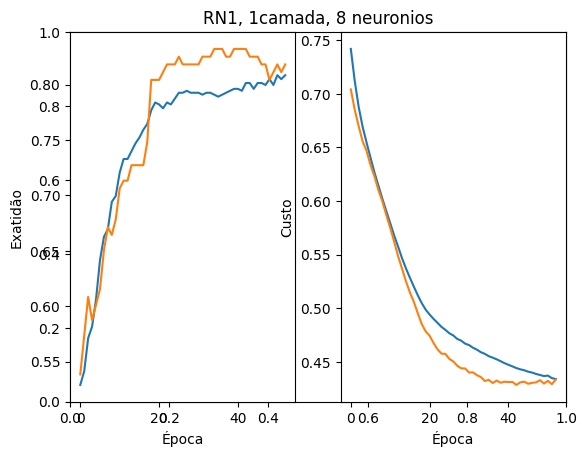

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


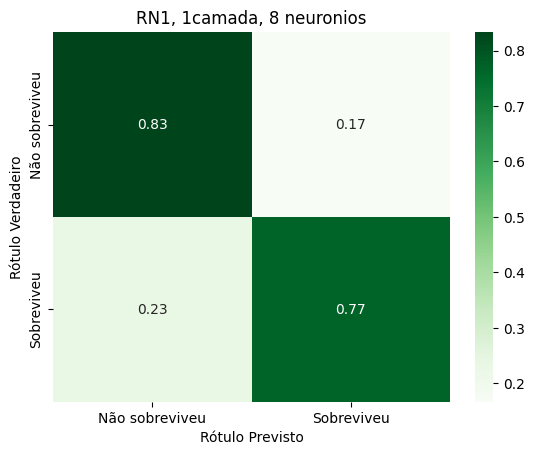

              precision    recall  f1-score   support

           0       0.86      0.83      0.85       114
           1       0.72      0.77      0.75        65

    accuracy                           0.81       179
   macro avg       0.79      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [55]:
modelo_nn("RN1, 1camada, 8 neuronios",[8])

In [41]:
display(performance)

,Train Accuracy,Test Accuracy,Test f1
"RN1, 1camada, 5neuronios",0.81,0.82,0.80
"RN1, 1camada, 5 neuronios, val + earlystop",0.79,0.82,0.80
"RN1, 1camada, 8 neuronios",0.76,0.35,0.33


# Aumentar o número de camadas

## Rede neuronal com duas camadas

Pode-se  criar uma rede neuronal mais profunda adicionando camadas de neurónios.  


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

None


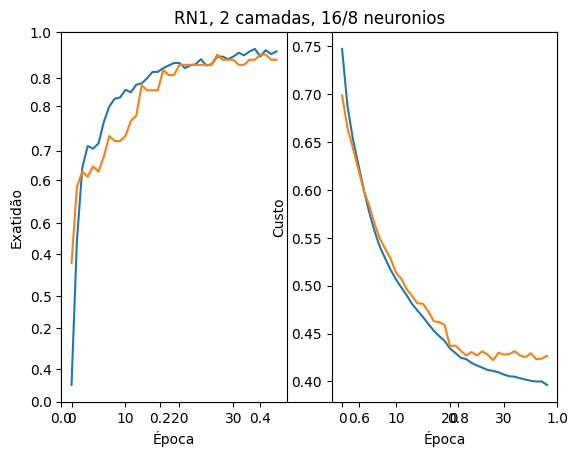

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


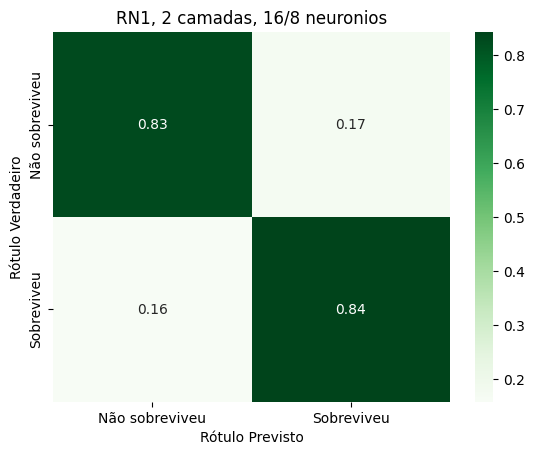

              precision    recall  f1-score   support

           0       0.92      0.83      0.87       122
           1       0.70      0.84      0.76        57

    accuracy                           0.83       179
   macro avg       0.81      0.83      0.82       179
weighted avg       0.85      0.83      0.84       179



In [56]:
modelo_nn("RN1, 2 camadas, 16/8 neuronios",[16,8])

In [57]:
display(performance.sort_values(by="Test f1", ascending=False))

,Train Accuracy,Test Accuracy,Test f1
"RN1, 2 camadas, 16/8 neuronios",0.84,0.83,0.82
"RN1, 1camada, 5neuronios",0.81,0.82,0.80
"RN1, 1camada, 8 neuronios",0.81,0.81,0.80
"RN1, 1camada, 5 neuronios, val + earlystop",0.69,0.68,0.64


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

None


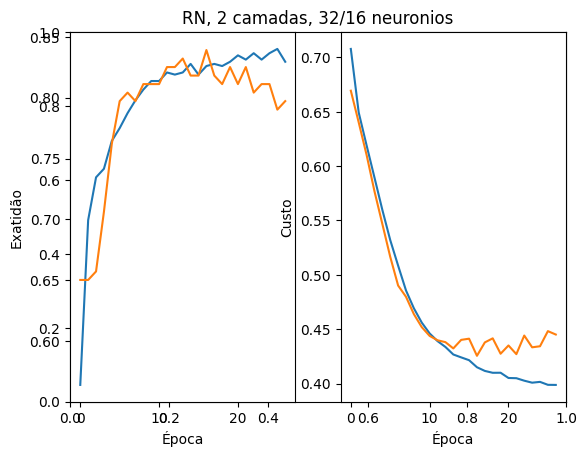

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


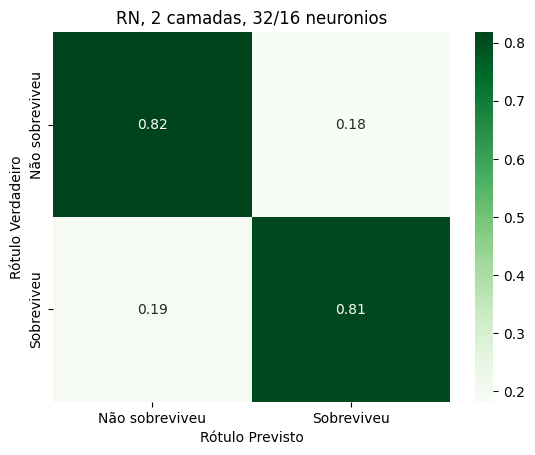

              precision    recall  f1-score   support

           0       0.90      0.82      0.86       121
           1       0.68      0.81      0.74        58

    accuracy                           0.82       179
   macro avg       0.79      0.81      0.80       179
weighted avg       0.83      0.82      0.82       179



In [58]:
modelo_nn("RN, 2 camadas, 32/16 neuronios",[32,16])

In [59]:
display(performance.sort_values(by="Test f1", ascending=False))

,Train Accuracy,Test Accuracy,Test f1
"RN1, 2 camadas, 16/8 neuronios",0.84,0.83,0.82
"RN1, 1camada, 5neuronios",0.81,0.82,0.80
"RN1, 1camada, 8 neuronios",0.81,0.81,0.80
"RN, 2 camadas, 32/16 neuronios",0.83,0.82,0.80
"RN1, 1camada, 5 neuronios, val + earlystop",0.69,0.68,0.64


## Rede neuronal com 3 camadas

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

None


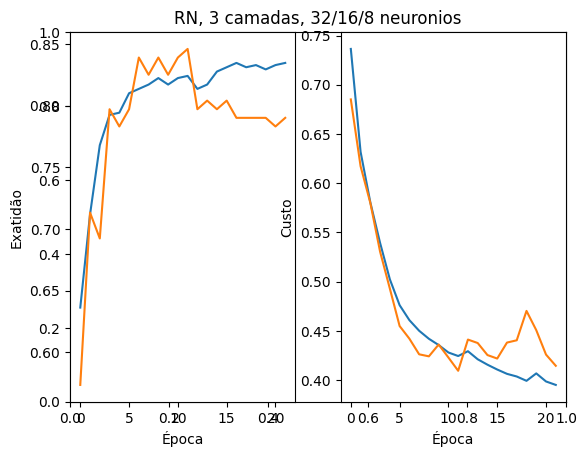

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


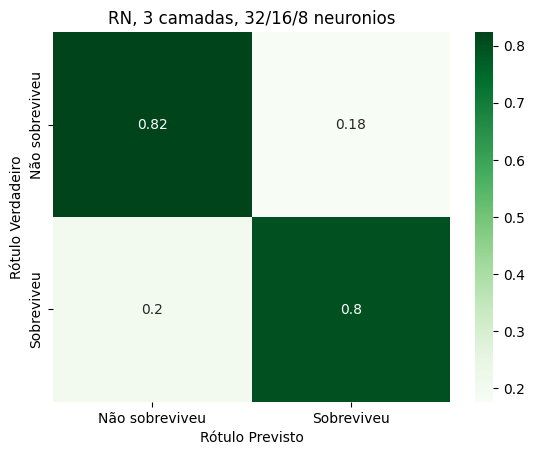

              precision    recall  f1-score   support

           0       0.89      0.82      0.86       119
           1       0.70      0.80      0.74        60

    accuracy                           0.82       179
   macro avg       0.79      0.81      0.80       179
weighted avg       0.83      0.82      0.82       179



In [60]:
modelo_nn("RN, 3 camadas, 32/16/8 neuronios",[32,16,8])

In [61]:
display(performance.sort_values(by="Test f1", ascending=False))

,Train Accuracy,Test Accuracy,Test f1
"RN1, 2 camadas, 16/8 neuronios",0.84,0.83,0.82
"RN1, 1camada, 5neuronios",0.81,0.82,0.80
"RN1, 1camada, 8 neuronios",0.81,0.81,0.80
"RN, 2 camadas, 32/16 neuronios",0.83,0.82,0.80
"RN, 3 camadas, 32/16/8 neuronios",0.83,0.82,0.80
"RN1, 1camada, 5 neuronios, val + earlystop",0.69,0.68,0.64


---